# Chapter 37 — Fatigue Measurement Programs: The Arithmetic of Damage
### *Modern Strain Gage Technology* — Companion Notebook

Companion notebook to Chapter 37 — Fatigue Measurement Programs: The Arithmetic of Damage.

Service loads are rarely constant. A vehicle encounters potholes, wind gusts, and acceleration events. A bridge sees traffic loads that vary minute by minute. A turbine blade experiences a spectrum of vibratory amplitudes that shifts with engine speed. To predict how long a component will last under this variable loading, an engineer needs three things: a measured strain history, a method to count the cycles in that history, and a damage model that converts cycle counts into a fraction of life consumed.

The standard tool for the first step is a strain **gage**. The standard tool for the second is **rainflow cycle counting** — the algorithm that traces the history like water flowing down a pagoda roof and extracts the stress reversals that actually drive crack growth. The standard tool for the third is **Miner's linear damage rule**, which sums the damage contributed by every counted cycle. This notebook builds the first two stages of that pipeline and then turns to the *mean-stress correction* that the damage step depends on.

**This notebook demonstrates:**
1. A variable-amplitude strain history with multiple frequency components and noise, reduced to its turning points and counted with a simplified rainflow algorithm (Figure 37.3).
2. The resulting cycle-amplitude histogram — the spectrum that a Miner's-rule life calculation consumes.
3. A **Goodman diagram** placing a measured operating point relative to the infinite-life boundary, showing why both the *mean* and the *alternating* stress must be measured (Figure 37.1).

In [1]:
# !pip install numpy matplotlib
# (Uncomment the line above when running in Google Colab.)

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11, 'axes.titlesize': 12})

# All figures are written here; the book includes these exact files, so the
# output filenames must not change.
OUT_DIR = Path("../src/media/ch37")
OUT_DIR.mkdir(parents=True, exist_ok=True)

---
## 1 — Rainflow Cycle Counting on a Variable-Amplitude Strain History

The synthetic strain history below combines three sinusoidal components with different frequencies and amplitudes, plus measurement noise — a simplified approximation of the kind of broadband signal a gage on a vehicle suspension or aircraft wing would record. The peak-valley extraction step reduces the raw time series to its turning points, discarding the intermediate samples that carry no additional fatigue information. The simplified rainflow algorithm then processes the turning-point sequence, identifying closed hysteresis loops.

Each closed loop represents one complete fatigue cycle at a specific amplitude (half-range). The rainflow histogram at the bottom groups these cycles by amplitude, producing the spectrum that Miner's rule needs to compute cumulative damage. The key observation from any real measured spectrum is the same as from this synthetic one: most of the cycles are at low amplitude and contribute little damage, while the rare high-amplitude events dominate the fatigue life. A test program designed without measuring those rare events will systematically over-predict the remaining life.

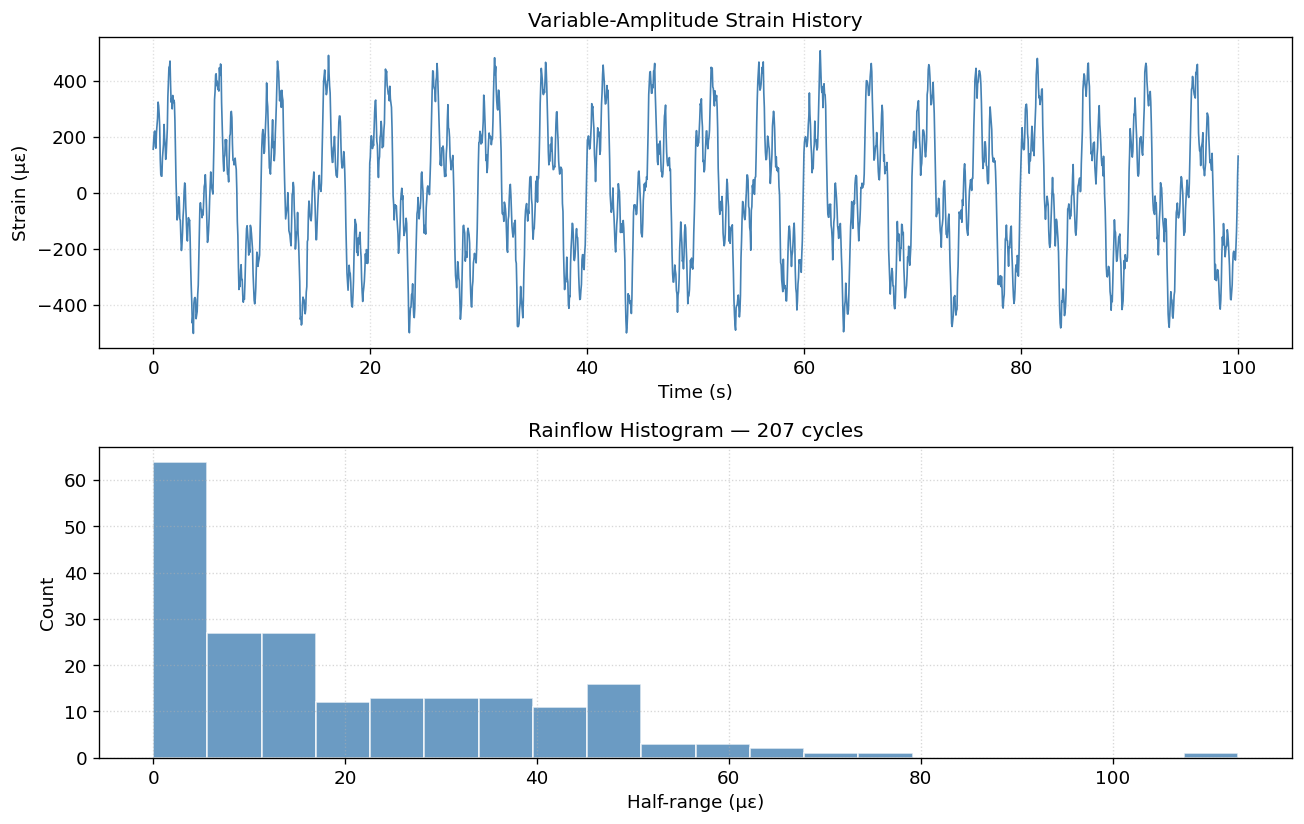

In [2]:
def peaks_valleys(series):
    """Reduce a strain time series to its turning points (local maxima and minima).

    The samples between reversals carry no additional fatigue information, so
    keeping only the peaks and valleys leaves exactly the sequence that
    rainflow counting operates on.
    """
    turning_points = [series[0]]
    for i in range(1, len(series) - 1):
        is_peak = series[i] > series[i - 1] and series[i] >= series[i + 1]
        is_valley = series[i] < series[i - 1] and series[i] <= series[i + 1]
        if is_peak or is_valley:
            turning_points.append(series[i])
    turning_points.append(series[-1])
    return np.array(turning_points)


def rainflow(turning_points):
    """Count closed hysteresis loops in a turning-point sequence (simplified rainflow).

    Applies the classic four-point rule: when the middle of four consecutive
    ranges is the smallest, its inner pair of points forms one closed cycle and
    is removed from the sequence. Returns each closed cycle's amplitude — half
    its strain range — the quantity a fatigue damage model consumes.
    """
    amplitudes = []
    stack = list(turning_points)
    while len(stack) >= 4:
        r1 = abs(stack[1] - stack[0])
        r2 = abs(stack[2] - stack[1])
        r3 = abs(stack[3] - stack[2])
        if r2 <= r1 and r2 <= r3:
            amplitudes.append(r2 / 2)   # amplitude = half the strain range
            stack.pop(1)
            stack.pop(1)
        else:
            stack.pop(0)
    return amplitudes


# --- Synthetic variable-amplitude strain history ------------------------------
# Three sinusoids of decreasing amplitude and increasing frequency, plus
# broadband measurement noise: a simplified stand-in for the gage signal from a
# vehicle suspension or an aircraft wing. The fixed seed makes it reproducible.
DURATION_S = 100.0     # record length (s)
N_SAMPLES = 2000       # number of evenly spaced samples
NOISE_UE = 20.0        # measurement-noise standard deviation (με)
COMPONENTS = [          # (amplitude με, frequency Hz, phase rad)
    (300, 0.2, 0.0),
    (150, 0.7, 0.5),
    (80, 2.1, 1.2),
]

np.random.seed(42)
t = np.linspace(0, DURATION_S, N_SAMPLES)
strain = sum(amp * np.sin(2 * np.pi * freq * t + phase)
             for amp, freq, phase in COMPONENTS)
strain = strain + np.random.normal(0, NOISE_UE, len(t))

turning_points = peaks_valleys(strain)
cycles = rainflow(turning_points)

fig, axes = plt.subplots(2, 1, figsize=(11, 7))
axes[0].plot(t, strain, 'steelblue', lw=1)
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Strain (με)')
axes[0].set_title('Variable-Amplitude Strain History')
axes[0].grid(True, linestyle=':', alpha=0.4)

axes[1].hist(cycles, bins=20, color='steelblue', alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Half-range (με)')
axes[1].set_ylabel('Count')
axes[1].set_title(f'Rainflow Histogram — {len(cycles)} cycles')
axes[1].grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig(OUT_DIR / 'fig37_nb1_fatigue_strain_history.png', bbox_inches='tight', dpi=150)
plt.show()

---
## Goodman Diagram and the Mean-Stress Correction

The Goodman criterion corrects the fully reversed endurance limit for a non-zero mean stress: $\sigma_a/\sigma_e + \sigma_m/\sigma_{UTS} = 1$. The cell below plots the Goodman line for a structural steel and places a measured operating point (mean 165 MPa, amplitude 138 MPa) inside the safe region, illustrating why both the mean and the alternating component must be measured.

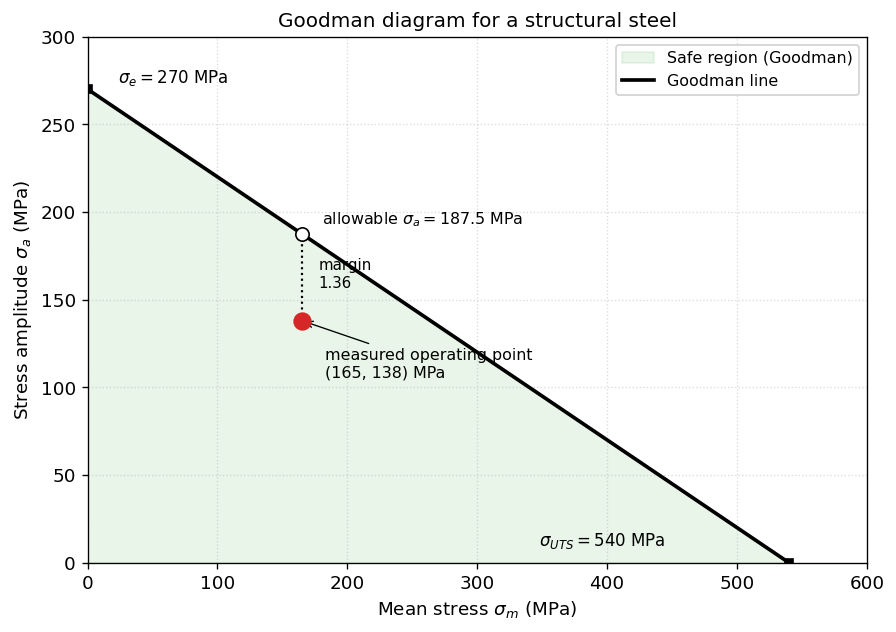

Goodman sum = 0.8167 ; allowable amp = 187.5 MPa ; margin = 1.36


In [3]:
# Goodman diagram for a structural steel, with a measured operating point.
se, suts = 270.0, 540.0          # endurance limit, UTS (MPa)
sm, sa = 165.0, 138.0            # measured mean & amplitude (MPa)
sa_allow = se * (1 - sm / suts)  # Goodman-allowable amplitude at this mean

fig, ax = plt.subplots(figsize=(7.6, 5.4))
ax.fill([0, suts, 0], [0, 0, se], color='#2ca02c', alpha=0.10, zorder=0,
        label='Safe region (Goodman)')
ax.plot([0, suts], [se, 0], 'k-', lw=2.2, label='Goodman line')
ax.plot(0, se, 'ks', ms=5); ax.annotate(r'$\sigma_e = 270$ MPa', (0, se),
        xytext=(18, 4), textcoords='offset points', fontsize=10)
ax.plot(suts, 0, 'ks', ms=5); ax.annotate(r'$\sigma_{UTS} = 540$ MPa', (suts, 0),
        xytext=(-150, 10), textcoords='offset points', fontsize=10)
ax.plot(sm, sa_allow, 'o', mfc='white', mec='k', ms=8, zorder=5)
ax.annotate(r'allowable $\sigma_a = 187.5$ MPa', (sm, sa_allow),
            xytext=(12, 6), textcoords='offset points', fontsize=9.5)
ax.plot([sm, sm], [sa, sa_allow], 'k:', lw=1.3)
ax.annotate('margin\n1.36', (sm, (sa + sa_allow) / 2),
            xytext=(10, -6), textcoords='offset points', fontsize=9)
ax.plot(sm, sa, 'o', color='#d62728', ms=10, zorder=6)
ax.annotate('measured operating point\n(165, 138) MPa', (sm, sa),
            xytext=(14, -34), textcoords='offset points', fontsize=9.5,
            arrowprops=dict(arrowstyle='->', lw=0.8))
ax.set_xlabel(r'Mean stress $\sigma_m$ (MPa)')
ax.set_ylabel(r'Stress amplitude $\sigma_a$ (MPa)')
ax.set_xlim(0, 600); ax.set_ylim(0, 300)
ax.grid(True, ls=':', alpha=0.45)
ax.legend(loc='upper right', fontsize=9.5, framealpha=0.9)
ax.set_title('Goodman diagram for a structural steel')
plt.tight_layout()
plt.savefig(OUT_DIR / 'fig37_nb2_goodman_diagram.png', dpi=150, bbox_inches='tight')
plt.show()
print('Goodman sum = %.4f ; allowable amp = %.1f MPa ; margin = %.2f'
      % (sa/se + sm/suts, sa_allow, sa_allow/sa))


---
## Where to take this next

- **Close the loop with Miner's rule.** Pair each rainflow amplitude with an S-N (or ε-N) curve for your material, convert every counted cycle to a damage fraction *n/N*, and sum them to a damage index *D*. Watch how a handful of high-amplitude cycles dominate *D* even though the histogram is crowded with small ones — the central lesson of the chapter, made quantitative.
- **Swap in a standard counter that also returns the mean.** Replace the simplified four-point routine with a full ASTM E1049 rainflow implementation that reports each cycle's *mean* as well as its amplitude, then build a two-dimensional amplitude-versus-mean matrix. Feed those means through the Goodman correction from the second figure so that high-mean cycles are penalized correctly rather than treated as fully reversed.
- **Probe the sampling limit.** Re-sample the strain history far below twenty points per cycle, re-run the counting, and confirm the aliasing warning from the chapter: under-sampling folds high-frequency content into false low-frequency cycles that rainflow will then faithfully — and wrongly — count as damage.